# Get the data needed for DeepSTARR 
to do: </br>
    - other data augmentation </br>
    - other normalisation method, see below </br>
Done:  </br> 
    - Try with log normalisation --> Tricky to evaluate, the base pair scores look better, but the overall correlations are slightly lower. Maybe would be improved by performing the same normalisation but without the log transformation, and scaling by a factor that gets numbers in the 0 - 5 range </br> 

In [1]:
here::i_am("atac/archR/DeepSTARR/D35_early.ipynb")

#####################
## Define settings ##
#####################

source(here::here("settings.R"))
source(here::here("utils.R"))
suppressPackageStartupMessages({
    library(BSgenome.Mmusculus.UCSC.mm10)
    library(parallel)
})

here() starts at /rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/code



In [134]:
# Options
args = list()

# ATAC
args$singlecell_matrix = file.path(io$basedir, '/processed/atac/archR/Matrices/PeakMatrix_summarized_experiment.rds')
# RNA
args$sce <- file.path(io$basedir,"processed/rna/SingleCellExperiment.rds")
args$metadata <- file.path(io$basedir,"results/rna/mapping/sample_metadata_after_mapping.txt.gz")
args$features = 2500
args$npcs = 10

args$outdir = file.path(io$basedir, 'results/atac/archR/DeepSTARR/D35_early/')
dir.create(args$outdir, recursive=T, showWarnings=F)

# RNA

In [6]:
# Get scRNA-seq trajectory
sample_metadata <- fread(args$metadata) %>%
  .[pass_rnaQC==TRUE & doublet_call==FALSE & day=='D3.5']

sce <- load_SingleCellExperiment(args$sce, cells=sample_metadata$cell, normalise = TRUE)


Loading required package: scuttle



In [135]:
decomp <- modelGeneVar(sce)
decomp <- decomp[decomp$mean > 0.01,]
hvgs <- decomp[order(decomp$FDR),] %>% head(n=args$features) %>% rownames

# Subset SingleCellExperiment
sce_filt <- sce[hvgs,]

In [136]:
sce_filt <- runPCA(sce_filt, ncomponents = args$npcs, ntop=args$features)
pca.dt <- reducedDim(sce_filt,"PCA") %>% round(3) %>% as.data.table(keep.rownames = T) %>% setnames("rn","cell") %>%
    merge(.,sample_metadata, by='cell')


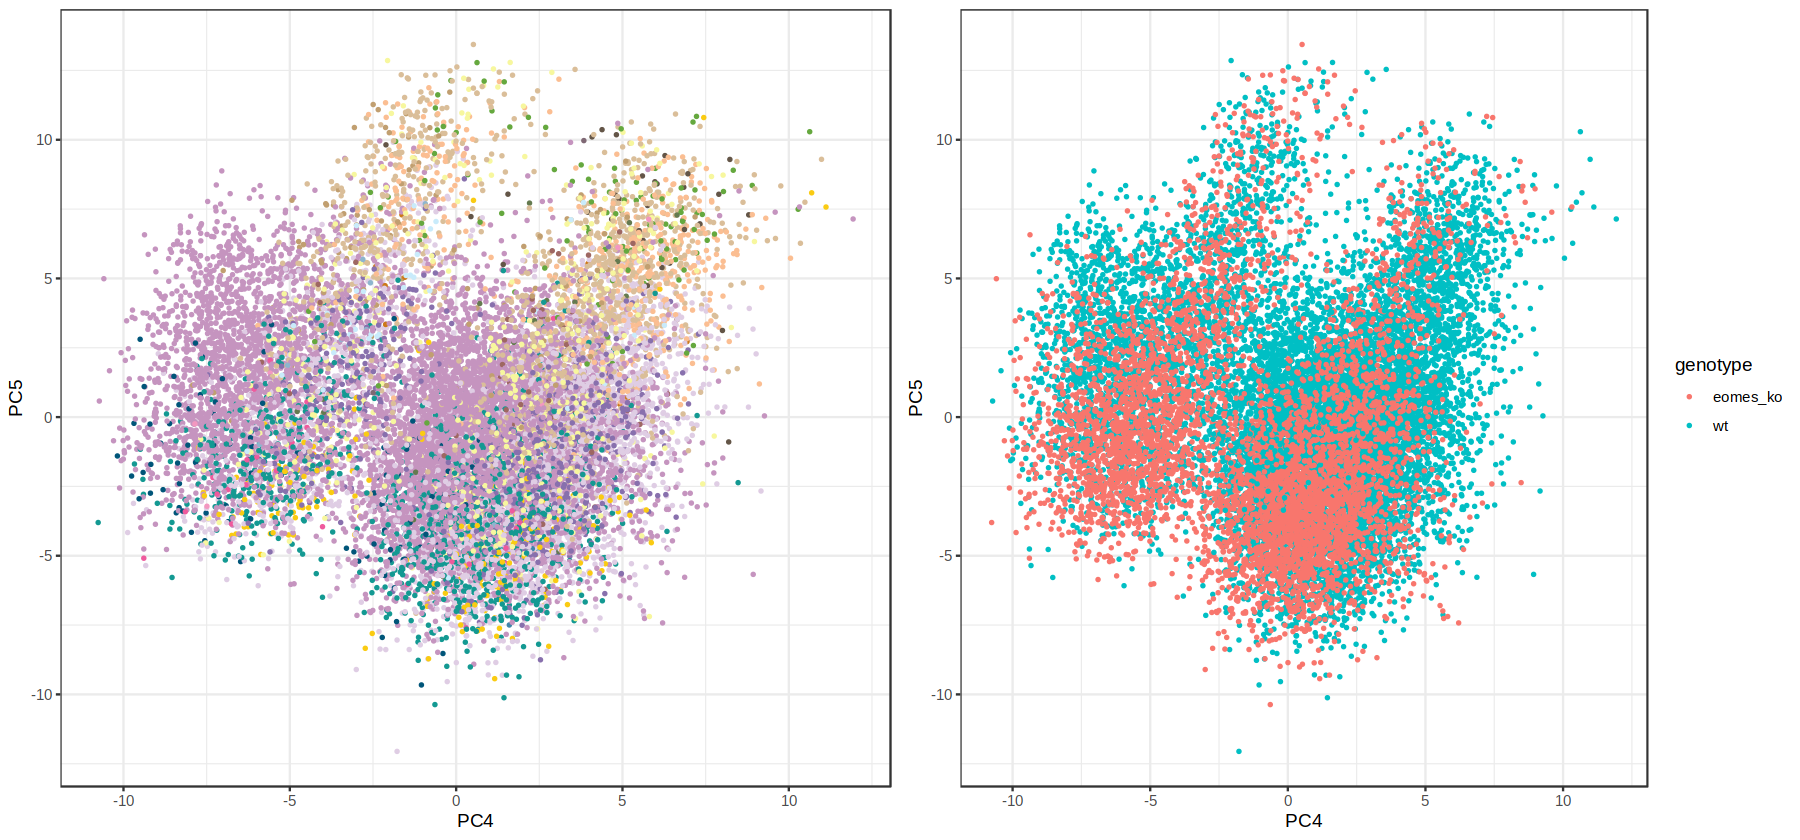

In [149]:
options(repr.plot.width=15)
p1 = ggplot(pca.dt, aes(PC4, PC5, col=celltype)) + 
    geom_point(size=0.5) + 
    scale_color_manual(values=opts$celltype.colors) + 
    theme_bw() + theme(legend.position='none')
p2 = ggplot(pca.dt, aes(PC4, PC5, col=genotype)) + 
    geom_point(size=0.5) + 
    theme_bw()
ggarrange(p1, p2)

In [138]:
library(destiny)

In [155]:
dm <- DiffusionMap(reducedDim(sce_filt,"PCA")[,-4], n_pcs= 9)# args$n_pcs -1) # remove batch PC4

In [156]:
dm.dt <- dm@eigenvectors[,c(1,2)] %>% round(10) %>% as.data.table(keep.rownames = T) %>% setnames("rn","cell") %>%
    merge(.,sample_metadata, by='cell')

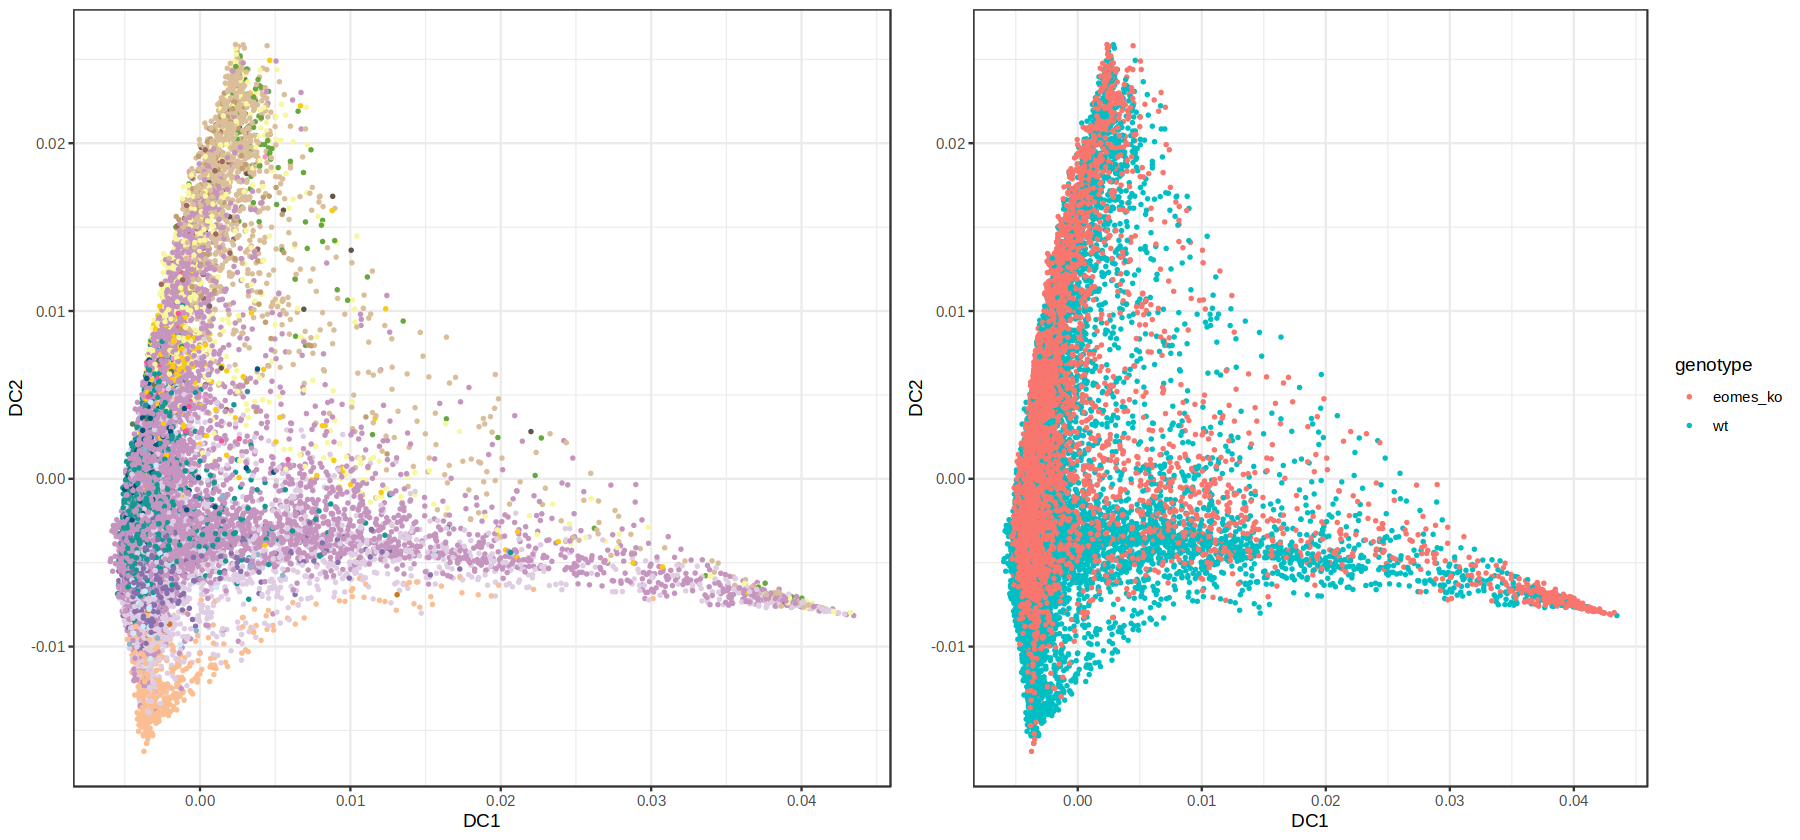

In [158]:
p1 = ggplot(dm.dt, aes(DC1, DC2, col=celltype)) + 
    geom_point(size=0.5) + 
    scale_color_manual(values=opts$celltype.colors) + 
    theme_bw() + theme(legend.position='none')
p2 = ggplot(dm.dt, aes(DC1, DC2, col=genotype)) + 
    geom_point(size=0.5) + 
    theme_bw()
ggarrange(p1, p2)

In [159]:
# Everything above DC2 = 0.002 seems quite similar between the KD and WT, so these are the cells I am going to use
cells = dm.dt[DC2>=0.002, cell]

In [161]:
table(dm.dt[DC2>=0.002, genotype])


eomes_ko       wt 
    2280     2500 

# ATAC

In [162]:
# Load files
Peakmatrix = readRDS(args$singlecell_matrix)

In [163]:
cells_keep = cells[cells %in% colnames(Peakmatrix)]

In [164]:
Peakmatrix_filt = Peakmatrix[,cells_keep]

In [165]:
genotype = sample_metadata[match(cells_keep, cell), genotype]

In [166]:
Peakmatrix_filt@assays@data$counts = Peakmatrix_filt@assays@data$PeakMatrix

In [167]:
Peakmatrix_bu = Peakmatrix_filt

In [168]:
Peakmatrix_filt = aggregateAcrossCells(Peakmatrix_filt, id=genotype)

In [169]:
Peakmatrix_filt

class: RangedSummarizedExperiment 
dim: 238993 2 
metadata(0):
assays(1): counts
rownames(238993): chr1:3003473-3004073 chr1:3035580-3036180 ...
  chrX:169923276-169923876 chrX:169925415-169926015
rowData names(1): idx
colnames(2): eomes_ko wt
colData names(40): BlacklistRatio nDiFrags ... ids ncells

In [170]:
# Split data in train, val, and test sets
# Before did it with the sample function, but this results in different peaks every time
# all_peaks = rownames(Peakmatrix_filt)
# paste0('total peaks: ', length(all_peaks))
# tot_peaks = length(all_peaks)
# val_peaks = sample(all_peaks, tot_peaks/12)
# paste0('peaks in val set: ', length(val_peaks))
# train_peaks = all_peaks[!all_peaks%in%val_peaks]
# paste0('peaks without validation set: ', length(train_peaks))
# test_peaks = sample(train_peaks, tot_peaks/12)
# paste0('peaks in test set: ', length(test_peaks))
# train_peaks = train_peaks[!train_peaks%in%test_peaks]
# paste0('peaks without validation & test set: ', length(train_peaks))

# Train and validation are around 1/10th of train set

all_peaks = rownames(Peakmatrix_filt)
paste0('total peaks: ', length(all_peaks))
tot_peaks = length(all_peaks)
val_test = tot_peaks/12
val_peaks = all_peaks[1:val_test]
paste0('peaks in val set: ', length(val_peaks))
train_peaks = all_peaks[!all_peaks%in%val_peaks]
paste0('peaks without validation set: ', length(train_peaks))
test_peaks = all_peaks[val_test+1:val_test*2]
paste0('peaks in test set: ', length(test_peaks))
train_peaks = train_peaks[!train_peaks%in%test_peaks]
paste0('peaks without validation & test set: ', length(train_peaks))

[1] "total peaks: 238993"

[1] "peaks in val set: 19916"

[1] "peaks without validation set: 219077"

[1] "peaks in test set: 19916"

[1] "peaks without validation & test set: 199161"

### Define functions

In [171]:
# transform peaks to 249 bp flanking centre
# Little bit different than DeepSTARR paper, where they also take regions flanking the centre, but would need to recalculate the accessibility of the new bins
parse_peaks = function(peaks){
    data.table(peak=peaks,
               chr=strsplit(peaks, ':') %>% map_chr(1),
               start=as.numeric(strsplit(strsplit(peaks, ':') %>% map_chr(2), '-') %>% map_chr(1)),
               end=as.numeric(strsplit(strsplit(peaks, ':') %>% map_chr(2), '-') %>% map_chr(2))) %>%
    .[,centre:=round((start+end)/2, 0)] %>% # Get centre of peak and round in case original peak width was an odd number
    .[,`:=`(start=NULL,end=NULL)] %>%
    .[,`:=`(start = centre - 124,
            end = centre + 124)] %>%
    .[,new_peak:=paste0(chr, ':', start, '-', end)]
}

# prepare fasta file
get_fa = function(x, peakset=train_peaks){ # x=row
    # positive strand
    pos_peak = paste0('>', peakset[x,new_peak], '_+')
    pos_fa = paste(as.character(as.vector(getSeq(Mmusculus, peakset[x,chr],
                                         start=peakset[x,start], end=peakset[x,end]))), collapse="")
    # negative strand
    neg_peak = paste0('>', peakset[x,new_peak], '_-')
    neg_fa = paste(as.character(as.vector(reverseComplement(DNAString(pos_fa)))), collapse="")
    
    # return
    tmp = c(pos_peak, pos_fa, neg_peak, neg_fa)
    return(tmp)
}

## Get fasta files

In [172]:
########################
### Get & save Fastas ##
########################

# Train set
train_peakset = parse_peaks(train_peaks)
train_fa = mclapply(1:nrow(train_peakset), get_fa, peakset=train_peakset, mc.cores=24) %>% unlist()
writeLines(train_fa , sprintf('%s/train.fa', args$outdir))

In [ ]:
# Validation set
val_peakset = parse_peaks(val_peaks)
val_fa = mclapply(1:nrow(val_peakset), get_fa, peakset=val_peakset, mc.cores=24) %>% unlist()
writeLines(val_fa , sprintf('%s/val.fa', args$outdir))

In [ ]:
# Test set
test_peakset = parse_peaks(test_peaks)
test_fa = mclapply(1:nrow(test_peakset), get_fa, peakset=test_peakset, mc.cores=24) %>% unlist()
writeLines(test_fa , sprintf('%s/test.fa', args$outdir))

## Get scores

#### log2 normalisation

In [ ]:
assayNames(Peakmatrix_filt)[1] <- "counts"
Peakmatrix_filt@assays@data$logcounts <- log2(1e6*(sweep(Peakmatrix_filt@assays@data$counts,2,colSums(Peakmatrix_filt@assays@data$counts),"/"))+1)

In [ ]:
lognormalised = Peakmatrix_filt@assays@data$logcounts

In [ ]:
gghistogram(as.vector(lognormalised))

In [ ]:
rownames(lognormalised) = rownames(Peakmatrix_filt)

In [ ]:
# get peak sets (after reloading notebook)
train_peakset = parse_peaks(train_peaks)
val_peakset = parse_peaks(val_peaks)
test_peakset = parse_peaks(test_peaks)

In [ ]:
##################
### Save scores ##
##################
# scores need to be duplicated, since we have positive and negative strand in .fa file
# Train set
train_sequence_activity = round(lognormalised[rep(train_peakset$peak, each=2),], 8)
fwrite(train_sequence_activity,  sprintf('%s/train_sequence_activity_log.txt', args$outdir), sep = '\t')

# Validation set
val_sequence_activity = round(lognormalised[rep(val_peakset$peak, each=2),], 8)
fwrite(val_sequence_activity,  sprintf('%s/val_sequence_activity_log.txt', args$outdir), sep = '\t')

# Test set
test_sequence_activity = round(lognormalised[rep(test_peakset$peak, each=2),], 8)
fwrite(test_sequence_activity,  sprintf('%s/test_sequence_activity_log.txt', args$outdir), sep = '\t')

# Differential testing

In [173]:
head(sample_metadata$genotype)

[1] "wt" "wt" "wt" "wt" "wt" "wt"

In [174]:
genotype_sample = sample_metadata[match(cells_keep, cell), ] %>%
    .[,gt_sample:=paste0(genotype, '_', sample)] %>%
    .$gt_sample

In [175]:
head(genotype_sample)

[1] "wt_2_Eo_DEG_G9_day3_5_VC" "wt_2_Eo_DEG_G9_day3_5_VC"
[3] "wt_2_Eo_DEG_G9_day3_5_VC" "wt_2_Eo_DEG_G9_day3_5_VC"
[5] "wt_2_Eo_DEG_G9_day3_5_VC" "wt_2_Eo_DEG_G9_day3_5_VC"

In [176]:
Peakmatrix_bu$genotype = sample_metadata[match(cells_keep, cell), genotype]

In [177]:
Peakmatrix_filt = aggregateAcrossCells(Peakmatrix_bu, id=genotype_sample)

In [178]:
Peakmatrix_filt

class: RangedSummarizedExperiment 
dim: 238993 4 
metadata(0):
assays(1): counts
rownames(238993): chr1:3003473-3004073 chr1:3035580-3036180 ...
  chrX:169923276-169923876 chrX:169925415-169926015
rowData names(1): idx
colnames(4): eomes_ko_2_Eo_DEG_G9_day3_5_dTAG
  eomes_ko_rv_eo_deg_day3_5_dtag wt_2_Eo_DEG_G9_day3_5_VC
  wt_rv_eo_deg_day3_5_control
colData names(40): BlacklistRatio nDiFrags ... ids ncells

In [179]:
library(edgeR)

In [180]:
# Create DGEList
atac.dge <- DGEList(assay(Peakmatrix_filt, "counts"))

# Define design matrix (with intercept)
design <- model.matrix(~Peakmatrix_filt$genotype)

In [181]:
# Estimate dispersions
atac.dge <- estimateDisp(atac.dge,design)

# Fit GLM
fit <- glmQLFit(atac.dge,design)

# Likelihood ratio test
lrt <- glmQLFTest(fit)

In [182]:
# Construct output data.frame
out <- topTags(lrt, n=nrow(lrt))$table %>% as.data.table(keep.rownames=T) %>%
	setnames(c("feature","logFC","logCPM","LR","p.value","padj_fdr")) %>%
	.[,c("logCPM","LR","p.value"):=NULL] %>%
	.[,c("padj_fdr","logFC"):=list(signif(padj_fdr,digits=3),round(logFC,3))] %>%
	.[is.na(logFC),c("logFC","padj_fdr"):=list(0,1)] %>%
	setorder(padj_fdr, na.last=T)

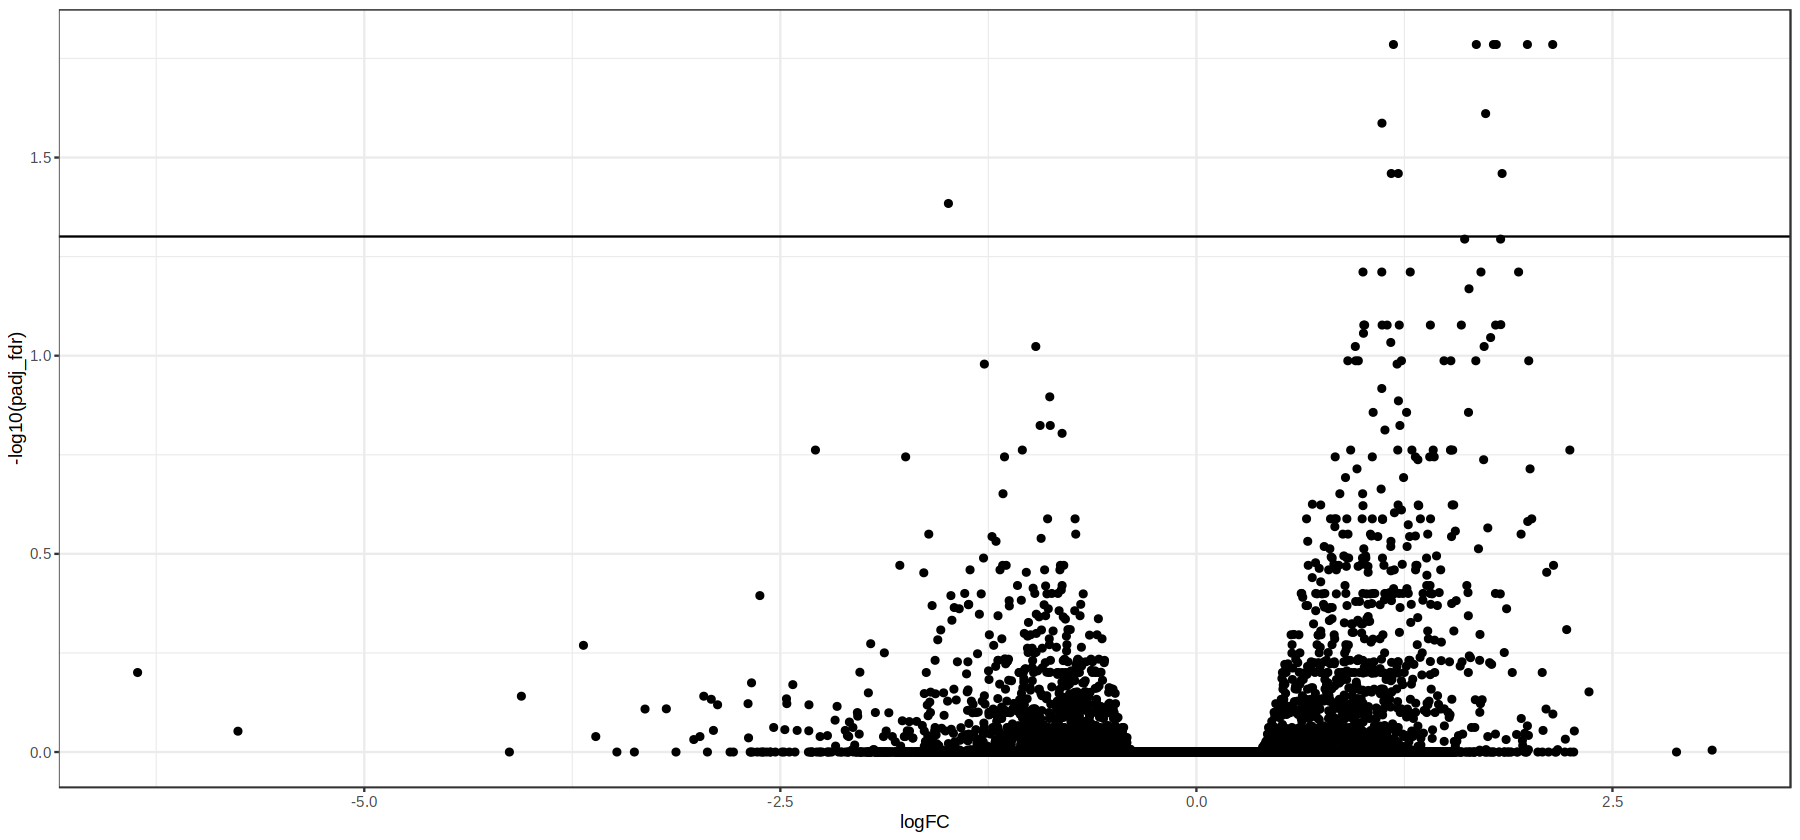

In [184]:
ggplot(out, aes(logFC, -log10(padj_fdr))) + 
    geom_point() + 
    geom_hline(yintercept=-log10(0.05)) + theme_bw()

In [185]:
test = out[abs(logFC)>1] %>% .[,`:=`(chr=strsplit(feature, ':') %>% map_chr(1),
               start=as.numeric(strsplit(strsplit(feature, ':') %>% map_chr(2), '-') %>% map_chr(1)),
               end=as.numeric(strsplit(strsplit(feature, ':') %>% map_chr(2), '-') %>% map_chr(2)))] %>%
    .[,centre:=round((start+end)/2, 0)] %>% # Get centre of peak and round in case original peak width was an odd number
    .[,`:=`(start=NULL,end=NULL)] %>%
    .[,`:=`(start = centre - 124,
            end = centre + 124)] %>%
    .[,new_peak:=paste0(chr, ':', start, '-', end)] %>%
    .[order(-abs(logFC))]

#### Inspection fastas

In [9]:
################################
### Get Fastas for inspection ##
################################
# prepare fasta file
get_fa_ss = function(x, peakset=train_peaks){ # x=row
    # positive strand
    pos_peak = paste0('>', peakset[x,new_peak], '_+')
    pos_fa = paste(as.character(as.vector(getSeq(Mmusculus, peakset[x,chr],
                                         start=peakset[x,start], end=peakset[x,end]))), collapse="")
    # return
    tmp = c(pos_peak, pos_fa)
    return(tmp)
}

##### Marker peaks from Ricard

In [24]:
marker_peaks = fread(args$markers)

In [25]:
marker_peaks_filt = marker_peaks[celltype %in% args$celltypes] %>% 
    .[order(-logFC)]

In [27]:
get_markers_fa = function(ct, n=200){
    peaks_tmp = parse_peaks(marker_peaks_filt[celltype==ct, feature] %>% head(n))
    fa_tmp = mclapply(1:nrow(peaks_tmp), get_fa_ss, peakset=peaks_tmp, mc.cores=24) %>% unlist()
    writeLines(fa_tmp , sprintf('%s/%s_inspection_markers.fa', args$outdir, ct))    
}

In [29]:
for(i in args$celltypes){
    get_markers_fa(i, n = 200)
}

#### peaks from Luke

In [76]:
get_markers_fa = function(peaks, name, n=2000, cores=24){
    peaks_tmp = parse_peaks(peaks) %>% head(n)
    fa_tmp = mclapply(1:nrow(peaks_tmp), get_fa_ss, peakset=peaks_tmp, mc.cores=cores) %>% unlist()
    fa_tmp = fa_tmp[grep('Error',fa_tmp, invert =T)] # for some reason sometimes throws errors so remove as tmp fix
    writeLines(fa_tmp , sprintf('%s/%s.fa', args$outdir, name))    
}

In [13]:
# SCL in FLK+ cells
SCL_FLK = fread(sprintf('%s/SCL_Flk1+_mm10.bed', args$outdir))

In [77]:
get_markers_fa(SCL_FLK$V4, name='SCL_FLK', n=2000, cores=24) 

Warning message in mclapply(1:nrow(peaks_tmp), get_fa_ss, peakset = peaks_tmp, mc.cores = cores):
“scheduled cores 15, 16, 17, 18, 19 encountered errors in user code, all values of the jobs will be affected”
